# GradientBoostingRegressor Model Development and Evaluation Script

## Modeling Pipeline

- **Baseline Model Development:** A standard GradientBoostingRegressor model was trained using default hyperparameters to establish a performance benchmark.
- **Hyperparameter Optimization:** The baseline model was optimized using ***`Optuna`*** and ***`RandomizedSearchCV`***, enabling selection of the most effective hyperparameter configurations.
- **Cross-Validation and Robustness Assessment:** Each model variant was subjected to cross-validation to evaluate stability and generalization performance.
- **Overfitting Analysis:** A detailed comparison between cross-validation metrics and test set results was conducted. Additional metrics, including ***`RMSE ratio`*** and ***`R² gap`***, were computed to quantify overfitting and assess model generalization.

---

## Persisted Artifacts

To ensure reproducibility, transparency, and extendability, the following artifacts have been saved:

- **Optimized Model Performance:** Individual CSV files capturing the performance of each model variant:
    - ***GradientBoostingRegressor (Baseline)***
    - ***GradientBoostingRegressor (Optuna)***
    - ***GradientBoostingRegressor (RandomizedSearchCV)***

These files include detailed evaluation metrics for each variant.

- **Best Variation Performance:** A CSV file containing only the metrics of the best-performing model variation, allowing quick reference without reviewing all variants.

- **Summary of Model Performance:** A consolidated CSV file including:
    - Cross-validation results (`CV MSE`, ` MAE`, `CV RMSE`, `CV R² Score`, `CV MAPE`)
    - Test set results (`Test MSE`, `Test MAE`, `Test RMSE`, `Test R² Score`, `Test MAPE`)
    - Overfitting metrics (`R² gap`, `RMSE ratio`)
    - Overfitting status and model generalization

This file is extendable, allowing addition of new model evaluations in the future.

- **Overfitting DataFrame:** An extendable CSV specifically capturing overfitting analysis metrics across all models and variations.

- **Best Model Variation:** The serialized best-performing GradientBoostingRegressor model for deployment or further inference.

Together, these artifacts provide a complete, reproducible record of the modeling process, facilitating model tracking, comparison, and deployment.

## Import Libraries and Root Configuration

In [1]:
""" Configure the utilities module path for imports """
import sys
import os
from pathlib import Path

# get project root as parent of current working directory
project_root = Path(os.getcwd()).parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
# records and calculations
import pandas as pd
import numpy as np

# avoid minor warnings
import warnings
warnings.filterwarnings('ignore')

# read file path
from pathlib import Path

# visualizations
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# optimization
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# import helper functions
from utilities import Evaluator, DataHandler, ModelPersister

## Load Dataset and Artifacts

In [3]:
df, x, y = DataHandler.load_dataset("../data/encoded_dataset.csv")
artifacts = DataHandler.load_artifacts("../artifacts/feature-selection", cv_required=True)

In [4]:
# check dataset loading
df.head()

,ItemWeight,MRP,OutletAge,Visibility,IsVisibile,IsGroceryStore,PricePerWeight,ItemType,FatContent_Regular,OutletSize_Medium,OutletSize_Small,LocationType_Tier 2,LocationType_Tier 3,OutletType_Supermarket Type1,OutletType_Supermarket Type2,OutletType_Supermarket Type3,OutletSales
0,9.500,171.3448,26,0.034600,1,0,18.036295,7.369344,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,7.777469
1,18.000,170.5422,23,0.046381,1,0,9.474567,7.338780,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,8.040434
2,17.600,111.7202,28,0.073364,1,0,6.347739,7.294114,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,7.025718
3,8.325,41.6138,23,0.029409,1,0,4.998655,7.369344,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,5.650018
4,12.850,155.5630,28,0.128594,1,0,12.106070,7.372674,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,8.348656


In [5]:
# check input features
x.head()

,ItemWeight,MRP,OutletAge,Visibility,IsVisibile,IsGroceryStore,PricePerWeight,ItemType,FatContent_Regular,OutletSize_Medium,OutletSize_Small,LocationType_Tier 2,LocationType_Tier 3,OutletType_Supermarket Type1,OutletType_Supermarket Type2,OutletType_Supermarket Type3
0,9.500,171.3448,26,0.034600,1,0,18.036295,7.369344,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,18.000,170.5422,23,0.046381,1,0,9.474567,7.338780,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
2,17.600,111.7202,28,0.073364,1,0,6.347739,7.294114,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,8.325,41.6138,23,0.029409,1,0,4.998655,7.369344,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
4,12.850,155.5630,28,0.128594,1,0,12.106070,7.372674,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [6]:
# check target feature
y.head()

0    7.777469
1    8.040434
2    7.025718
3    5.650018
4    8.348656
Name: OutletSales, dtype: float64

In [7]:
# load train/test split data
x_train, x_test, y_train, y_test = artifacts['x_train'], artifacts['x_test'], artifacts['y_train'], artifacts['y_test']
cv = artifacts['cv']

# Baseline Modeling

## Train GradientBoostingRegressor Model

In [8]:
# create baseline model
baseline_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=1,
    subsample=1.0,
    max_features=None,
    random_state=42,
)

# train baseline mode
baseline_model.fit(x_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


## Apply Model to Make Predication

In [9]:
# baseline prediction on train and test set
y_train_pred_baseline = baseline_model.predict(x_train)
y_test_pred_baseline = baseline_model.predict(x_test)

## Evaluating Model Performance
Calculating Errors for train and test data

In [10]:
# evaluation of train metrics
train_metrics_baseline = Evaluator.calculate_metrics(y_train, y_train_pred_baseline)

# evaluation of test metrics
test_metrics_baseline = Evaluator.calculate_metrics(y_test, y_test_pred_baseline)

In [11]:
# Baseline Model Performance
baseline_perf = Evaluator.performance_table(train_metrics_baseline, test_metrics_baseline)

print("GradientBoostingRegressor - Baseline Modeling Performance")
display(baseline_perf)

GradientBoostingRegressor - Baseline Modeling Performance


,Metrics,Training,Test
0,MSE,0.2500,0.2717
1,MAE,0.3863,0.4039
2,RMSE,0.5000,0.5213
3,R2 Score,0.7569,0.7425
4,MAPE,5.5824,5.9465


# Optuna Optimzation

## Find Best Parameters

In [12]:
# define objective function
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 5, 15),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "random_state": 42,
        "warm_start": True
    }


    # train model with hyperparameter tuning
    model = GradientBoostingRegressor(**params)
    model.fit(x_train, y_train)

    # predict & evaluate on TRAIN (for speed); Optuna will rank by this
    y_pred = model.predict(x_train)
    rmse = np.sqrt(mean_squared_error(y_train, y_pred))

    return rmse

In [13]:
# enable pruning to skip bad trials early
pruner = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=20)

# create optuna study object
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=pruner
)

# optuna optimization with hyperparameter tuning
print("🚀 Starting Optuna optimization for Random Forest (30 trials, with pruning)...")
study.optimize(objective, n_trials=30, show_progress_bar=True)

🚀 Starting Optuna optimization for Random Forest (30 trials, with pruning)...


Best trial: 12. Best value: 0.0050138: 100%|██████████| 30/30 [04:46<00:00,  9.55s/it]


## Train optimized model

In [14]:
# Build final model (ensure max_samples handled correctly)
best_params = study.best_params.copy()
# train and fit optimized model
optuna_model = GradientBoostingRegressor(**best_params)
optuna_model.fit(x_train, y_train)

,loss,'squared_error'
,learning_rate,0.17918159673964662
,n_estimators,482
,subsample,0.8715792259594299
,criterion,'friedman_mse'
,min_samples_split,20
,min_samples_leaf,6
,min_weight_fraction_leaf,0.0
,max_depth,14
,min_impurity_decrease,0.0
,init,None


## Apply Model to Make Predictions

In [15]:
# apply model to make predictions on train and test set
y_train_pred_optuna = optuna_model.predict(x_train)
y_test_pred_optuna = optuna_model.predict(x_test)

## Evaluating Optimized Model Performance
Calculating Errors for train and test data

In [16]:
# calculate train and test metrics
# return [mse, mae, rmse, r2, mape]
train_metrics_optuna = Evaluator.calculate_metrics(y_train, y_train_pred_optuna)
test_metrics_optuna = Evaluator.calculate_metrics(y_test, y_test_pred_optuna)

In [17]:
# performance table of optuna optimization
optuna_perf = Evaluator.performance_table(train_metrics_optuna, test_metrics_optuna)
print("GradientBoostingRegressor - Optuna Optimized Modeling Performance")
display(optuna_perf)

GradientBoostingRegressor - Optuna Optimized Modeling Performance


,Metrics,Training,Test
0,MSE,0.0000,0.3560
1,MAE,0.0033,0.4678
2,RMSE,0.0050,0.5966
3,R2 Score,1.0000,0.6627
4,MAPE,0.0451,6.8279


#  RandomizedSearchCV Optimzation

## Train RandomizedSearchCV Model

In [18]:
# Parameter distribution
param_dist = {
    "n_estimators": randint(100, 800),
    "learning_rate": uniform(0.01, 0.19),
    "max_depth": randint(2, 9),
    "min_samples_split": randint(2, 21),
    "min_samples_leaf": randint(1, 11),
    "subsample": uniform(0.6, 0.4),
    "max_features": ["sqrt", "log2", None]
}

# create RandomizedSearchCV model
randomSearch = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=30,                                 # start with 30 iterations
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

# fit the model
randomSearch.fit(x_train, y_train)

,estimator,GradientBoost...ndom_state=42)
,param_distributions,"{'learning_rate': <scipy.stats....001CA1CA2A0B0>, 'max_depth': <scipy.stats....001CA1CA2BBB0>, 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': <scipy.stats....001CA1DB00250>, ...}"
,n_iter,30
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [19]:
# find the best parameters from RandomizedSearchCV
randomSearch_model = randomSearch.best_estimator_

## Apply Model to Make Predictions

In [20]:
# make predictions on train and test set
y_train_pred_random = randomSearch_model.predict(x_train)
y_test_pred_random = randomSearch_model.predict(x_test)

## Evaluating Optimized Model Performance
Calculating Errors for train and test data

In [22]:
# calculate train and test metrics
train_metrics_random = Evaluator.calculate_metrics(y_train, y_train_pred_random)
test_metrics_random = Evaluator.calculate_metrics(y_test, y_test_pred_random)

In [23]:
# performance table of randomizedSearch optimization
random_perf = Evaluator.performance_table(train_metrics_random, test_metrics_random)

print("GradientBoostingRegressor - RandomizedSearchCV Optimized Modeling Performance")
display(random_perf)

GradientBoostingRegressor - RandomizedSearchCV Optimized Modeling Performance


,Metrics,Training,Test
0,MSE,0.2604,0.2683
1,MAE,0.3938,0.4001
2,RMSE,0.5103,0.5180
3,R2 Score,0.7468,0.7458
4,MAPE,5.7019,5.8926


# Cross Valiation (All Models)

In [24]:
# cross validation of all models
cv_baseline = Evaluator.cv_evaluate(baseline_model, x_train, y_train, cv)
cv_optuna = Evaluator.cv_evaluate(optuna_model, x_train, y_train, cv)
cv_random = Evaluator.cv_evaluate(randomSearch_model, x_train, y_train, cv)

In [25]:
# Evaluate cross-validation results
cv_df = pd.DataFrame({
    "Model": ["GBR (Baseline)", "GBR (Optuna)", "GBR (RandomizedSearchCV)"],
    "CV MSE": [cv_baseline['CV MSE'], cv_optuna['CV MSE'], cv_random['CV MSE']],
    "CV MAE": [cv_baseline['CV MAE'], cv_optuna['CV MAE'], cv_random['CV MAE']],
    "CV RMSE": [cv_baseline['CV RMSE'], cv_optuna['CV RMSE'], cv_random['CV RMSE']],
    "CV R2": [cv_baseline['CV R2'], cv_optuna['CV R2'], cv_random['CV R2']],
    "CV MAPE": [cv_baseline['CV MAPE'], cv_optuna['CV MAPE'], cv_random['CV MAPE']]
}).round(4)

print("Cross-Validation Results:")
display(cv_df)

Cross-Validation Results:


,Model,CV MSE,CV MAE,CV RMSE,CV R2,CV MAPE
0,GBR (Baseline),0.2768,0.4064,0.5262,0.7304,5.8992
1,GBR (Optuna),0.3693,0.4763,0.6077,0.6403,6.8440
2,GBR (RandomizedSearchCV),0.2738,0.4036,0.5232,0.7334,5.8564


# Summarize Models Performance

In [26]:
# selected models
models = ["GBR (Baseline)", "GBR (Optuna)", "GBR (RandomizedSearchCV)"]

# test metrics of all models
test_metrics = [test_metrics_baseline, test_metrics_optuna, test_metrics_random]

# performance summary including cross validation results
performance_summary = Evaluator.summary_builder(models, cv_df, test_metrics)

In [27]:
# Display the final performance summary table
print("Overall Model Performance:")
display(performance_summary)

Overall Model Performance:


,Model,CV MSE,CV MAE,CV RMSE,CV R2,CV MAPE,Test MSE,Test MAE,Test RMSE,Test R2,Test MAPE
0,GBR (Baseline),0.2768,0.4064,0.5262,0.7304,5.8992,0.2717,0.4039,0.5213,0.7425,5.9465
1,GBR (Optuna),0.3693,0.4763,0.6077,0.6403,6.8440,0.3560,0.4678,0.5966,0.6627,6.8279
2,GBR (RandomizedSearchCV),0.2738,0.4036,0.5232,0.7334,5.8564,0.2683,0.4001,0.5180,0.7458,5.8926


# Overfitting Analysis

In [28]:
# Overfitting analysis of all models

rows = []
for _, row in performance_summary.iterrows():
    # Extract metrics needed for assess_overfitting
    cv_r2 = row['CV R2']
    test_r2 = row['Test R2']
    cv_rmse = row['CV RMSE']
    test_rmse = row['Test RMSE']
    
    # get overfitting and generalization status
    gap, rmse_ratio, overfit_status, gen_status = Evaluator.assess_overfitting(
        cv_r2=cv_r2,
        test_r2=test_r2,
        cv_rmse=cv_rmse,
        test_rmse=test_rmse,
        tolerance=0.05
    )
    
    # build row
    rows.append({
        "Model": row['Model'],
        "CV RMSE": row['CV RMSE'],
        "CV R2": row['CV R2'],
        "Test RMSE": row['Test RMSE'],
        "Test R2": row['Test R2'],
        "R2 Gap": gap,
        "RMSE Ratio": rmse_ratio,
        "Overfitting Status": overfit_status,
        "Model Status (Generalization)": gen_status
    })

overfit_df = pd.DataFrame(rows).round(4)

In [29]:
print("GradientBoostingRegressor - Overfitting Analysis:")
display(overfit_df)

GradientBoostingRegressor - Overfitting Analysis:


,Model,CV RMSE,CV R2,Test RMSE,Test R2,R2 Gap,RMSE Ratio,Overfitting Status,Model Status (Generalization)
0,GBR (Baseline),0.5262,0.7304,0.5213,0.7425,-0.0121,0.9907,Low,Good
1,GBR (Optuna),0.6077,0.6403,0.5966,0.6627,-0.0224,0.9817,Low,Fair
2,GBR (RandomizedSearchCV),0.5232,0.7334,0.5180,0.7458,-0.0124,0.9901,Low,Good


# Model Comparison (Visualization)

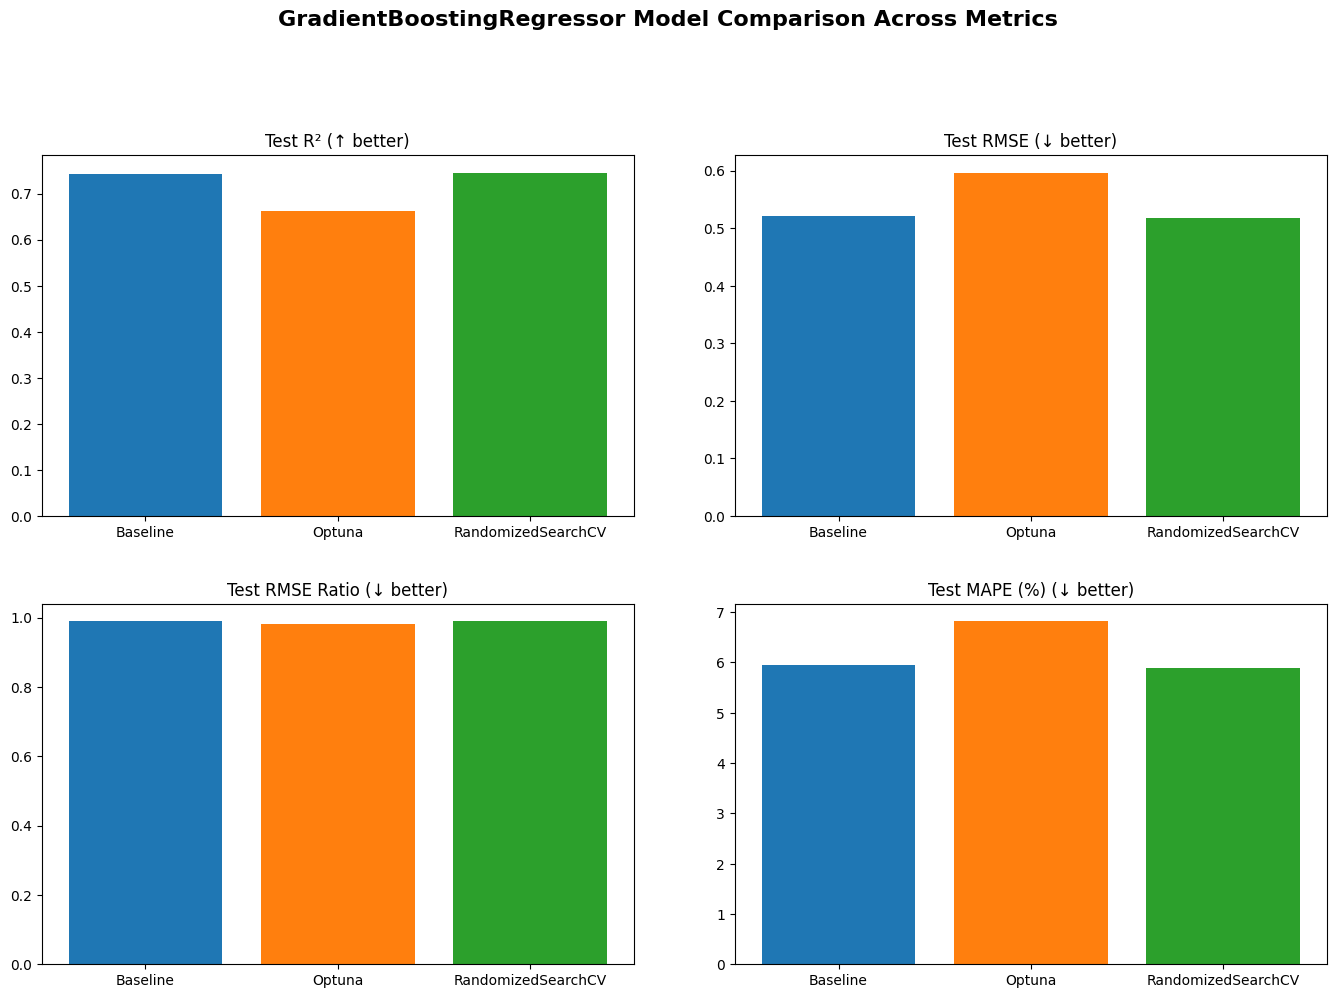

In [30]:
""" GradientBoostingRegressor Model Performance Comparison """

# Define metrics and titles
metrics = [
    "Test R2",
    "Test RMSE",
    "RMSE Ratio",
    "Test MAPE"
]

titles = [
    "Test R² (↑ better)",
    "Test RMSE (↓ better)",
    "Test RMSE Ratio (↓ better)",
    "Test MAPE (%) (↓ better)"
]

# Data preparation
model_labels = ["Baseline", "Optuna", "RandomizedSearchCV"]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

values_dict = {
    "Test R2": overfit_df["Test R2"].values,
    "Test RMSE": overfit_df["Test RMSE"].values,
    "RMSE Ratio": overfit_df["RMSE Ratio"].values,
    "Test MAPE": [test_metrics_baseline[4], test_metrics_optuna[4], test_metrics_random[4]]
}

# Figure setup
n_metrics = len(metrics)
rows, cols = 2, 2

fig, axes = plt.subplots(rows, cols, figsize=(14, 10))
axes = axes.flatten()

# Plot each metric dynamically
for i, metric in enumerate(metrics):
    ax = axes[i]
    values = values_dict[metric]
    
    # Create horizontal bar chart with model-specific colors
    bars = ax.bar(model_labels, values, color=colors)
    
    # Title and labels
    ax.set_title(titles[i], fontsize=12)
    

# Hide any unused subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Add overall title and adjust layout
plt.suptitle("GradientBoostingRegressor Model Comparison Across Metrics", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(pad=3.0, h_pad=3, w_pad=5)
plt.show()


# Final Summary of Model Performances

In [31]:
# final summary of all models performance
final_summary = pd.merge(performance_summary,
                    overfit_df[['Model', 'R2 Gap', 'RMSE Ratio', 'Overfitting Status', 'Model Status (Generalization)']],
                    on="Model",
                    how="outer")

In [32]:
print("Summary of The Models Performance:")
display(final_summary)

Summary of The Models Performance:


,Model,CV MSE,CV MAE,CV RMSE,CV R2,CV MAPE,Test MSE,Test MAE,Test RMSE,Test R2,Test MAPE,R2 Gap,RMSE Ratio,Overfitting Status,Model Status (Generalization)
0,GBR (Baseline),0.2768,0.4064,0.5262,0.7304,5.8992,0.2717,0.4039,0.5213,0.7425,5.9465,-0.0121,0.9907,Low,Good
1,GBR (Optuna),0.3693,0.4763,0.6077,0.6403,6.8440,0.3560,0.4678,0.5966,0.6627,6.8279,-0.0224,0.9817,Low,Fair
2,GBR (RandomizedSearchCV),0.2738,0.4036,0.5232,0.7334,5.8564,0.2683,0.4001,0.5180,0.7458,5.8926,-0.0124,0.9901,Low,Good


# Persist Best Model and Performance

In [33]:
# select best variant of GradientBoostingRegressor model
best_idx = final_summary["Test R2"].idxmax()
best_variant = final_summary.iloc[best_idx]

In [34]:
print("Best Variation From GradientBoosting Model:", best_variant["Model"])

Best Variation From GradientBoosting Model: GBR (RandomizedSearchCV)


In [35]:
# performance of best variation
best_variant = best_variant.to_frame(name='Value').rename_axis('Metrics').reset_index()

print("Performance of the best variation:")
display(best_variant)

Performance of the best variation:


,Metrics,Value
0,Model,GBR (RandomizedSearchCV)
1,CV MSE,0.2738
2,CV MAE,0.4036
3,CV RMSE,0.5232
4,CV R2,0.7334
5,CV MAPE,5.8564
6,Test MSE,0.2683
7,Test MAE,0.4001
8,Test RMSE,0.518
9,Test R2,0.7458


In [36]:
# model persister object
persister = ModelPersister(model_name="GBR")

In [37]:
# persit all variatnt performance
persister.save_performance(performance_summary)

GBR performance saved: ..\artifacts\model-performance\gbrPerformance.csv


In [38]:
# persist best variant performance
persister.save_performance(best_variant, "BestVariation")

GBR performance saved: ..\artifacts\model-performance\gbrBestVariation.csv


In [39]:
# aggregated model performance
persister.aggregated_performance(final_summary)

Appended to aggregated performance: ..\artifacts\model-performance\a_ModelPerformance.csv


In [40]:
# save overfitting overfitting analysis
persister.append_overfitting(overfit_df)

Appended to overfitting analysis: ..\artifacts\model-performance\a_overfittingAnalysis.csv


In [41]:
# save the best variant of XGBoost model
persister.save_model(randomSearch_model)

Model saved: ..\artifacts\models/gbr.pkl
